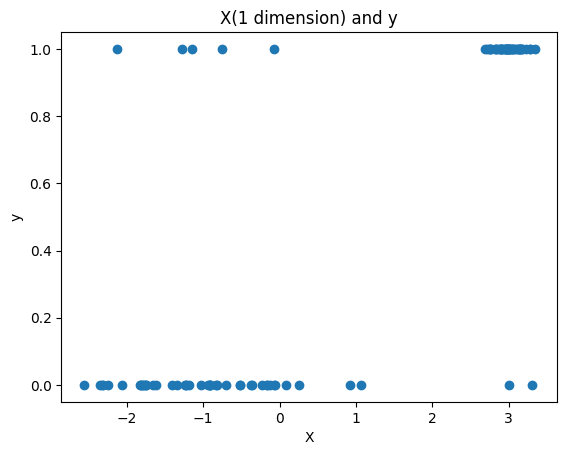

In [1]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

X,y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.5,0.5],
    flip_y=0.15,
    class_sep=2.0,
    hypercube=True,
    shift=1.0,
    scale=1.0,
    shuffle=True,
    random_state=88
)

# print(X.shape)

plt.scatter(X, y)
# plt.axhline(0.5, color='red', linestyle='-', label='threshold = 0.5')

plt.xlabel("X")
plt.ylabel("y")
plt.title("X(1 dimension) and y")
plt.show()

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X, y)
print("intercept:", model.intercept_)
print("coef:", model.coef_)

intercept: [-0.98497516]
coef: [[1.18885765]]


[0.0104407  0.01073221 0.01103177 0.0113396  0.01165592 0.01198095
 0.01231493 0.01265811 0.01301072 0.01337302 0.01374527 0.01412773
 0.01452067 0.01492439 0.01533915 0.01576525 0.01620299 0.01665269
 0.01711465 0.01758919 0.01807665 0.01857736 0.01909167 0.01961994
 0.02016252 0.02071979 0.02129213 0.02187993 0.02248357 0.02310348
 0.02374007 0.02439376 0.02506499 0.02575419 0.02646184 0.02718839
 0.02793431 0.02870009 0.02948623 0.03029323 0.03112161 0.0319719
 0.03284463 0.03374035 0.03465962 0.03560302 0.03657112 0.03756452
 0.03858382 0.03962965 0.04070262 0.04180337 0.04293257 0.04409086
 0.04527892 0.04649744 0.04774711 0.04902865 0.05034275 0.05169017
 0.05307163 0.0544879  0.05593972 0.05742788 0.05895316 0.06051635
 0.06211825 0.06375967 0.06544144 0.06716439 0.06892936 0.07073719
 0.07258873 0.07448486 0.07642643 0.07841433 0.08044943 0.08253262
 0.08466478 0.08684681 0.08907961 0.09136406 0.09370108 0.09609155
 0.09853637 0.10103645 0.10359267 0.10620592 0.10887708 0.11160

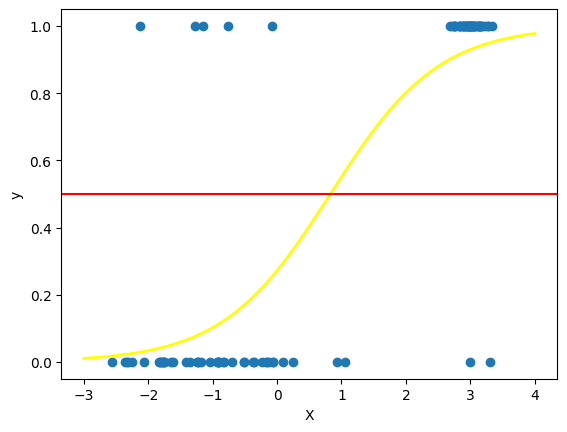

In [3]:
import numpy as np

x_range = np.linspace(-3,4, 300).reshape(-1, 1)

y_prob = model.predict_proba(x_range)[:, 1]
print(y_prob)
plt.scatter(X, y)
plt.plot(x_range, y_prob, color='yellow', linewidth=2, label='sigmoid')
plt.axhline(0.5, color='red', linestyle='-', linewidth=1.5, label='threshold = 0.5')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [4]:
def predict_probability(coefs, X):
    coef =coefs[0]
    intercept = coefs[1]

    z = coef * X + intercept

    probab = 1/(1 + np.exp(-z))
    return probab


# coef from the trained model
coef = model.coef_[0][0]
intercept = model.intercept_[0]

coefs = [coef, intercept]

my_probs = predict_probability(coefs, X)
skl_props = model.predict_proba(X)[:,1]
print("------\n",my_probs[:10])
print("------\n",skl_props[:10])

------
 [[0.16838474]
 [0.93807876]
 [0.08040988]
 [0.92079705]
 [0.93517695]
 [0.92542964]
 [0.07566453]
 [0.11193493]
 [0.93416244]
 [0.94218311]]
------
 [0.16838474 0.93807876 0.08040988 0.92079705 0.93517695 0.92542964
 0.07566453 0.11193493 0.93416244 0.94218311]


In [10]:
def predict_class(coefs, X):
    coef= coefs[0]
    intercept = coefs[1]

    z = coef * X + intercept

    probab = 1/(1 + np.exp(-z))

    classes = (probab >=0.5).astype(int)
    return classes.flatten()


# model.predict(X)

coef = model.coef_[0][0]
intercept = model.intercept_[0]

coefs = [coef, intercept]

#predictions
my_classes = predict_class(coefs, X)

# Sklearn predictions
skl_classes = model.predict(X)

print(np.array_equal(my_classes, skl_classes))


True


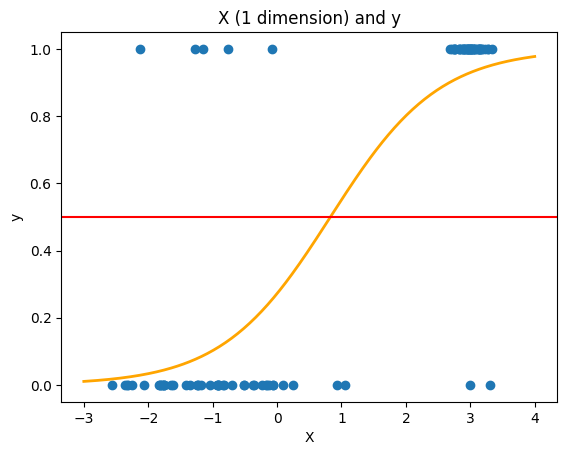

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(-3, 4, 300).reshape(-1, 1)
y_prob_range = model.predict_proba(x_range)[:, 1]

y_prob = model.predict_proba(X)[:, 1]
y_class = model.predict(X)

y_class_shifted = y_class.copy()
y_class_shifted[y_class == 0] = 0.1
y_class_shifted[y_class == 1] = 0.9

# Plot data
plt.scatter(X, y)

plt.plot(
    x_range,
    y_prob_range,
    color='orange',
    linewidth=2,
    label='sigmoid'
)

# Plot threshold
plt.axhline(
    0.5,
    color='red',
    linestyle='-',
    linewidth=1.5,
    label='threshold = 0.5'
)
plt.title("X (1 dimension) and y")
plt.xlabel("X")
plt.ylabel("y")

plt.show()

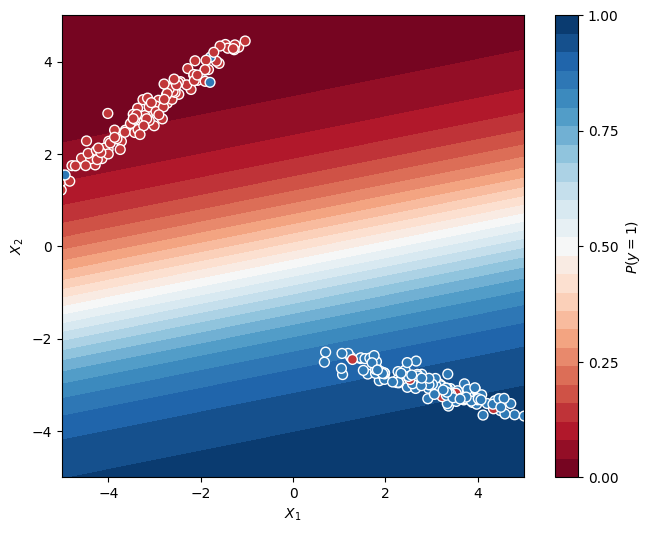

In [27]:
X, y = make_classification(n_features=2,
                           n_redundant=0,
                           n_samples=250,
                           n_classes=2,
                           n_clusters_per_class=1,
                           flip_y=0.05,
                           class_sep=3,
                           random_state=43)

model = LogisticRegression()
model.fit(X, y)


xx, yy = np.mgrid[-5:5:.01, -5:5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]

#if needed change the line below
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[:,0], X[:, 1], c=y, s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(aspect="equal",
       xlim=(-5, 5), ylim=(-5, 5),
       xlabel="$X_1$", ylabel="$X_2$")

plt.show()